In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/dataset/Online Retail.csv")

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Melihat Informasi Dataset

In [ ]:
print(df.shape)

df.info()

df.isnull().sum()

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Data Cleaning

In [ ]:
#Menghapus Missing Value

df = df.dropna(subset=['CustomerID'])

In [ ]:
#Menghapus Transaksi Cancel

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [ ]:
# Menghapus Quantity Negatif

df = df[df['Quantity'] > 0]

In [ ]:
# Menghapus Harga Negatif

df = df[df['UnitPrice'] > 0]

In [ ]:
# Menghapus Duplikasi

df.drop_duplicates(inplace=True)

Membuat kolom total harga

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [ ]:
# Konversi Tanggal

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

Membuat dataset RFM

In [ ]:
# Menentukan tanggal acuan

snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [ ]:
# Membuat RFM

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [ ]:
# Statistik Deskriptif

rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


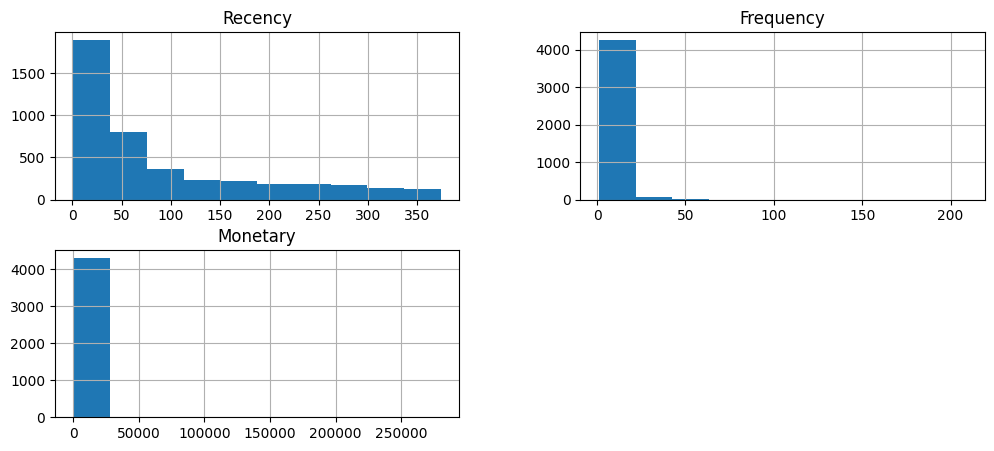

In [ ]:
# Visualisasi Distribusi Data

rfm.hist(figsize=(12,5))

plt.show()

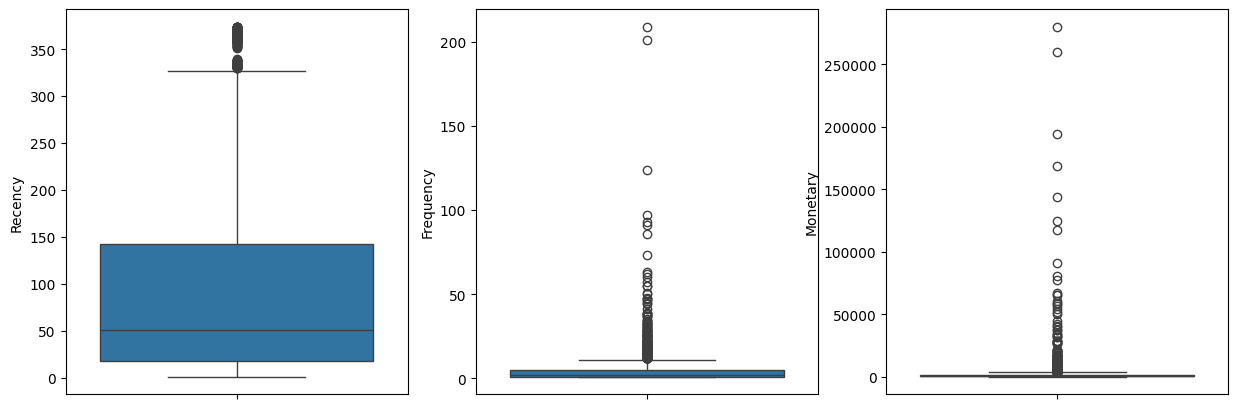

In [ ]:
# Boxplot Outlier

plt.figure(figsize=(15,5))

for i,col in enumerate(rfm.columns):

    plt.subplot(1,3,i+1)

    sns.boxplot(y=rfm[col])

plt.show()

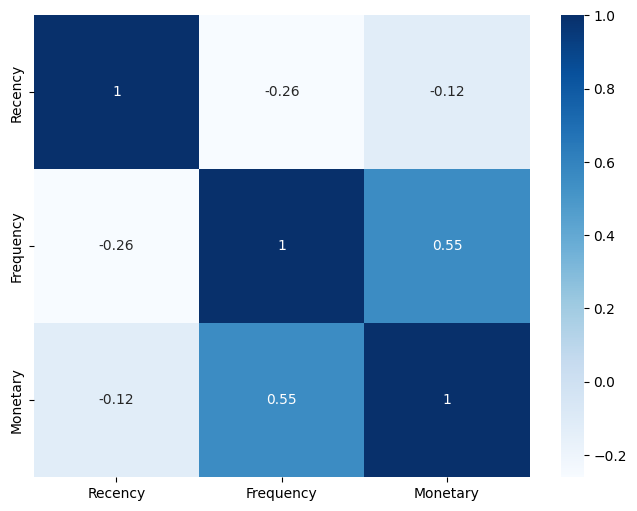

In [ ]:
# Heatmap Korelasi

plt.figure(figsize=(8,6))

sns.heatmap(
    rfm.corr(),
    annot=True,
    cmap='Blues'
)

plt.show()

In [ ]:
# Normalisasi data

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns
)

rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


In [ ]:
# Elbow Method

inertia = []

K = range(2,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)

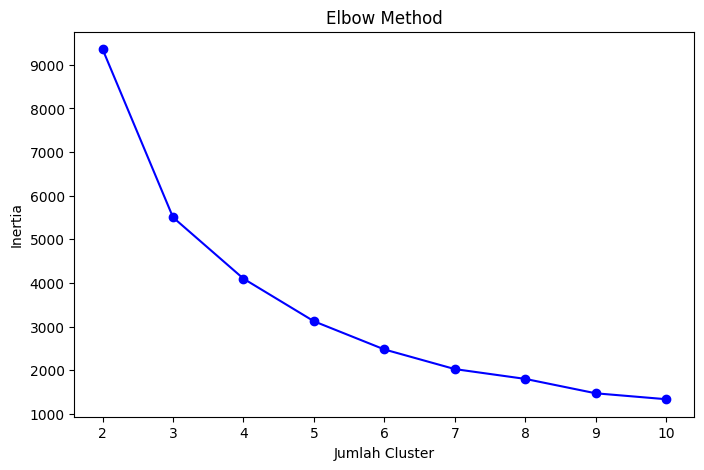

In [ ]:
# Grafik Elbow

plt.figure(figsize=(8,5))

plt.plot(K,inertia,'bo-')

plt.xlabel("Jumlah Cluster")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

K-Means Clustering

In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

rfm['KMeans_Cluster'] = kmeans.fit_predict(
    rfm_scaled
)

In [ ]:
# Evaluasi K-Means

sil_kmeans = silhouette_score(
    rfm_scaled,
    rfm['KMeans_Cluster']
)

dbi_kmeans = davies_bouldin_score(
    rfm_scaled,
    rfm['KMeans_Cluster']
)

print("Silhouette Score :", sil_kmeans)
print("DBI :", dbi_kmeans)

Silhouette Score : 0.5853238625904468
DBI : 0.6551660306675893


In [ ]:
rfm.groupby('KMeans_Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,40.98,4.85,2005.83
1,246.02,1.58,629.36
2,7.14,80.21,122748.79


DBSCAN

In [ ]:
dbscan = DBSCAN(
    eps=0.7,
    min_samples=5
)

rfm['DBSCAN_Cluster'] = dbscan.fit_predict(
    rfm_scaled
)

In [ ]:
# Evaluasi DBSCAN

if len(set(rfm['DBSCAN_Cluster'])) > 1:

    sil_dbscan = silhouette_score(
        rfm_scaled,
        rfm['DBSCAN_Cluster']
    )

    dbi_dbscan = davies_bouldin_score(
        rfm_scaled,
        rfm['DBSCAN_Cluster']
    )

    print("Silhouette :", sil_dbscan)
    print("DBI :", dbi_dbscan)

Silhouette : 0.8549271149448184
DBI : 0.9029292754897248


Agglomerative Clustering

In [ ]:
agg = AgglomerativeClustering(
    n_clusters=4
)

rfm['Agg_Cluster'] = agg.fit_predict(
    rfm_scaled
)

In [ ]:
# Evaluasi Agglomerative

sil_agg = silhouette_score(
    rfm_scaled,
    rfm['Agg_Cluster']
)

dbi_agg = davies_bouldin_score(
    rfm_scaled,
    rfm['Agg_Cluster']
)

print("Silhouette :", sil_agg)
print("DBI :", dbi_agg)

Silhouette : 0.6077080145270354
DBI : 0.8089616091314877


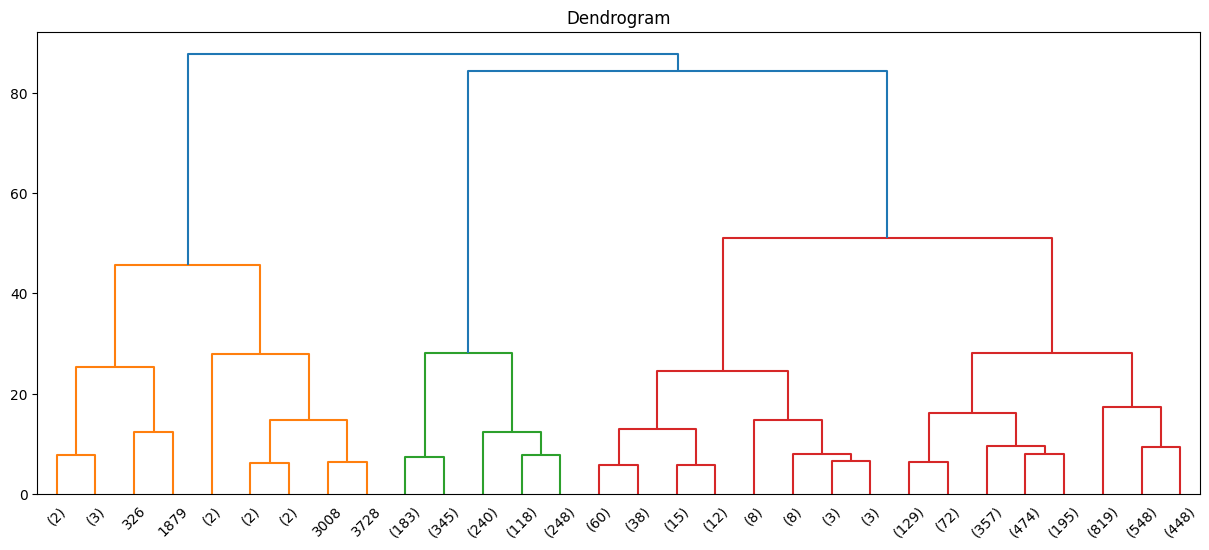

In [ ]:
# Dendogram

linked = linkage(
    rfm_scaled,
    method='ward'
)

plt.figure(figsize=(15,6))

dendrogram(
    linked,
    truncate_mode='lastp',
    p=30
)

plt.title("Dendrogram")

plt.show()

In [ ]:
# PCA untuk Visualisasi

pca = PCA(n_components=2)

pca_data = pca.fit_transform(
    rfm_scaled
)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

pca_df.head()

,PC1,PC2
0,4.107554,5.439993
1,0.743044,-0.670756
2,0.025230,-0.174675
3,-0.027491,-0.734603
4,-1.235593,1.834685


In [ ]:
print(pca_df.shape)

(4338, 2)


visualisasi K-Means

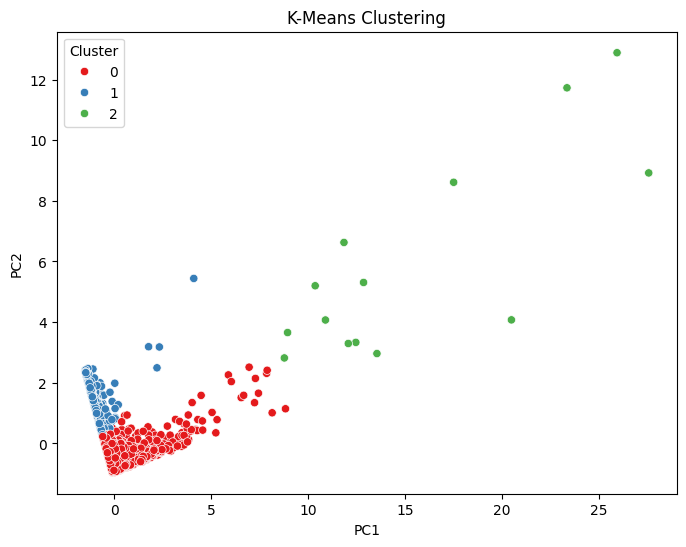

In [ ]:
pca_df['Cluster'] = rfm['KMeans_Cluster'].values

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title("K-Means Clustering")

plt.show()

visualisasi DBSCAN

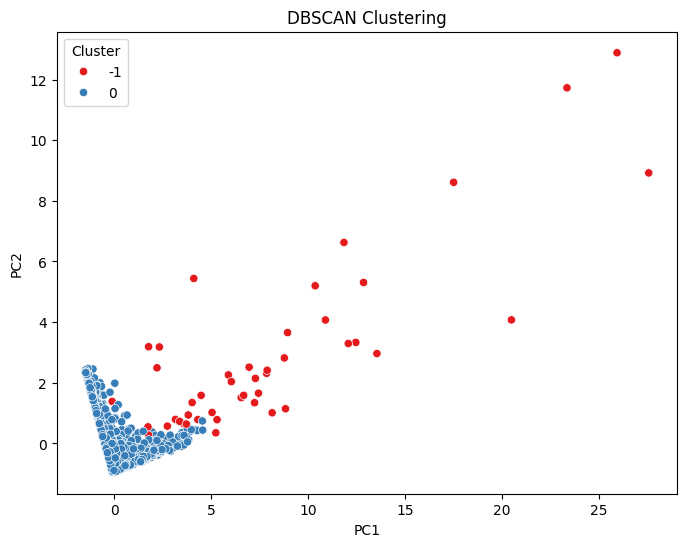

In [ ]:
pca_df['Cluster'] = rfm['DBSCAN_Cluster'].values

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title("DBSCAN Clustering")

plt.show()

visualisasi Agglomerative

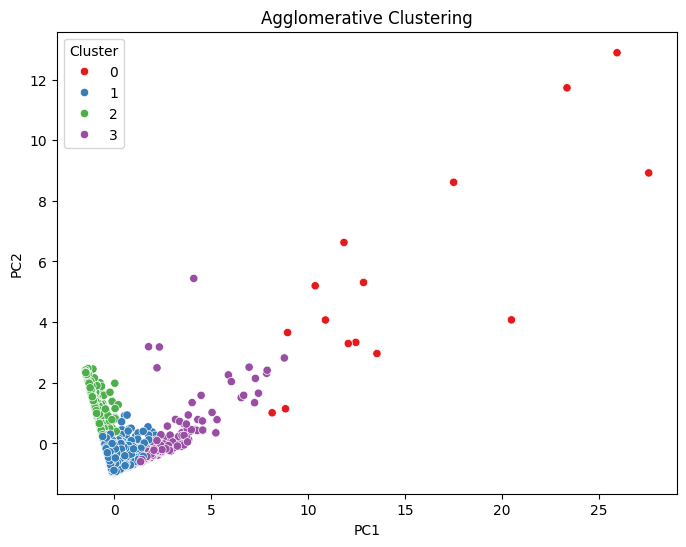

In [ ]:
pca_df['Cluster'] = rfm['Agg_Cluster'].values

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1'
)

plt.title("Agglomerative Clustering")

plt.show()

perbandingan model

In [ ]:
hasil = pd.DataFrame({

    'Algoritma' : [
        'K-Means',
        'DBSCAN',
        'Agglomerative'
    ],

    'Silhouette Score' : [
        sil_kmeans,
        sil_dbscan,
        sil_agg
    ],

    'Davies-Bouldin Index' : [
        dbi_kmeans,
        dbi_dbscan,
        dbi_agg
    ]
})

hasil

,Algoritma,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.585324,0.655166
1,DBSCAN,0.854927,0.902929
2,Agglomerative,0.607708,0.808962
